In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("../")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
# Define searches
from analysis import data_loading

data_dir = '/Users/wilka/git/research/results/human_dyna/'

searches = {
    # 'Paths': f'{data_dir}/user_data/*exps*/*v1*paths*.json',
    # 'Start': f'{data_dir}/user_data/*exps*/*v3*start*.json',
    # 'Plan (Tell)': f'{data_dir}/user_data/*exps*/*v1*r1-t0-plan*.json',
    # "Plan (Don't Tell)": f'{data_dir}/user_data/*exps*/*v1*r0-t0-plan*.json',
    'Shortcut': f'{data_dir}/user_data/*exps*/*v3*shortcut*.json',
}

valid_files = data_loading.get_valid_files(searches, verbose=True, plot=False)
len(valid_files)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Shortcut: 24/24 valid files


24

In [4]:
# valid_files = ['data2/user=47_name=exp_debug=2.json']

In [6]:
import polars as pl

# Create empty lists to store the data
rows = []

# Process each file
for file in valid_files:
    data = data_loading.read_dict_list_from_file(file)
    datum = data[-2]  # Get second to last entry
    
    def get_bool(x):
        if x.lower() == 'no': return False
        elif x.lower() == 'yes': return True
        else: raise NotImplementedError(x)
    
    # Get user_id
    user_id = datum['user_data']['user_id']
    
    # Process each notice value
    for i, (k, v) in enumerate(datum['data'].items()):
        noticed_value = get_bool(v)
        # Create a row with user_id and noticed value
        rows.append({
            'user_id': user_id,
            'noticed': noticed_value
        })

# Create DataFrame from the rows
df = pl.DataFrame(rows)
df.head()

user_id,noticed
i64,bool
3103635391,false
3103635391,false
3103635391,true
3103635391,false
2400757162,false


In [7]:
from analysis import housemaze_analysis


No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


In [8]:
stats_filename = os.path.join('.', 'shortcut_stats.txt')
stats_file = open(stats_filename, 'w')
results = housemaze_analysis.power_analysis_path_reuse(
      stats_file=stats_file,
      df=df,
      measure='noticed',
      plot=False)
stats_file.close()
with open(stats_filename, 'r') as f:
  print(f.read())


Analysis Results:
N = 24 participants (mean 4.0 trials per participant)
Mean reuse rate: 0.531 (SE: 0.079)

Normality Test (Shapiro-Wilk):
p = 0.002 (Non-normal distribution)

Wilcoxon signed-rank test:
statistic = 143.000
p = 0.291

Effect Size (r):
0.113

Required Sample Sizes:
Power 80%: N ≥ 128 participants
Power 90%: N ≥ 177 participants
Power 95%: N ≥ 223 participants



/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


(<Figure size 400x400 with 1 Axes>, <Axes: >)

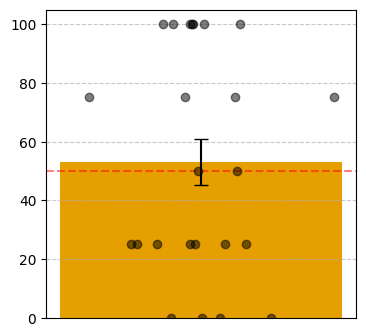

In [11]:
import matplotlib.pyplot as plt
# Create plot
human_data = {
    'means': 100 * results['mean'],
    'se': 100 * results['se'],
}
human_data['raw'] = 100 * results['reuse_rates']
fig, ax = plt.subplots(figsize=(4, 4))
housemaze_analysis.bar_plot_error(
    human_data=human_data,
    model_stats=None,
    ax=ax,
    legend=False,
)